### Part1: Logic and String Manipulation

##### DNA Helix Printer


Total # of rows in pattern = 2n-1
We print the pattern one row at a time (after completing one row we switch to next row).

Notice that each row has the same alphabet and it is a trivial pattern at that.

Row1 ---> A

Row2 ---> C

Row3 ---> G

Row4 ---> T  

Row5 ---> A (and then it repeats)

So depending upon the remainder the row index (i) leaves upon dividing by 4 we decide the alphabet to print in that row.

Now the question of what positions to put the alphabets in?

Notice that the helix patern repeats after 2n columns, so we only need to figure out the positions for the first 2n columns then repeat for the number of **turns** required.

In the top half of 2n block we only place alphabets when the row index(i) equals the column index(j) **OR** j = 2n - i + 1. 

In the bottom block we place alphabets when j = i + 1 **OR** j = 2n- i

(These rules are easily verifiable from seeing the pattern)

We just repeat this rule for every new 2n block.


In [21]:
def print_helix(n,turns):
    bases = ["T","A","C","G"]

    for i in range(1,2*n):
      char = bases[i%4]    #char to print in each row
        
      for t in range(1,turns+1):
         for j in range(1,2*n):
            if (i<=n):
                if (j==i or j==2*n-i+1):
                    print(char,end="")
                else:
                    print(" ",end="")
            if(i>n):
                if (j==2*n-i or j==i+1):
                    print(char,end="")
                else:
                    print(" ",end="")

      j=1                               #Handle the last column
      if (i<=n):
          if (j==i or j==2*n-i+1):
              print(char,end="")
          else:
              print(" ",end="")
      if (i>n):
          if(j==2*n-i or j==i+1):
              print(char,end="")
          else:
              print(" ",end="")
           
      print()                                    #Print new row
        

In [22]:
print_helix(4,11)            #Can verify by putting different value for n and turns


A      A      A      A      A      A      A      A      A      A      A      A
 C    C C    C C    C C    C C    C C    C C    C C    C C    C C    C C    C 
  G  G   G  G   G  G   G  G   G  G   G  G   G  G   G  G   G  G   G  G   G  G  
   TT     TT     TT     TT     TT     TT     TT     TT     TT     TT     TT   
  A  A   A  A   A  A   A  A   A  A   A  A   A  A   A  A   A  A   A  A   A  A  
 C    C C    C C    C C    C C    C C    C C    C C    C C    C C    C C    C 
G      G      G      G      G      G      G      G      G      G      G      G


### The Custom Sorter

We can use python's default sorted function for this purpose. The syntax of sorted function is 
<center> sorted(iterable, key = function) </center>

Where it can go through the iterable and appy the key function on each element and sort (in ascending order) according to the value returned by the function.

In our case the key is a tuple of functions 

<center> (len(s), -1*distinct_vowels(s), s)   </center>

We apply this key on each element of our list and generate a tuple for every element in our list, then it compares the tuple element wise and arranges in ascending order.

If the first element of the tuples don't match (same length) it compares the second element of the tuple and so on.

PS: There is a -1 in the second term because we want descending order


In [23]:
def sort_strings(s_list):
    
    vowels = set('aeiou')     #A set because we are going to do intersection to count the number of distinct vowels

    #Helper function to count the number of vowels

    def count_distinc_vowels(s):
        return len(set(s.lower()) & vowels)   #Makes a set of s (so removes duplicates and takes all lowercase) and takes intersection with vowels
        
    sorted_list = sorted(s_list,key=lambda s:(len(s),-count_distinc_vowels(s),s))  #key parameter expects a single function, lambda packs a bunch of functions to act as a single function
        


    return sorted_list

In [24]:
data = ["apple", "banana", "kiwi", "sky", "aeiou", "z"]
print(sort_strings(data))

['z', 'sky', 'kiwi', 'aeiou', 'apple', 'banana']


### Part2: Working with Data

### Sensor Data

To avoid using pandas we open the .csv file with open(filename.csv,"r") functionality (in read only mode). Removes the rows where the sensor reports error or voltage greater than 10.0.

Then we create 4 lists (1 for each sensor) and append the sensor voltages to corresponding lists and take the mean and standard deviation.

In [25]:
import math

def analyze_sensors(filename):
    file = []
    with open(filename,"r") as f:
        for line in f:
            line = line.strip()
            row = line.split(",")
            file.append(row)
    del file[0]      #Deletes header of the file and only gives the data

    S1 = []
    S2 = []
    S3 = []
    S4 = []

    for i in file:
        if (i[3]=='ERR' or float(i[2]) > 10.0):
            file.remove(i)
        
   
    for i in file:
        if (i[1] == 'S1'):
            S1.append(float(i[2]))
        
        if (i[1] == 'S2'):
            S2.append(float(i[2]))
        
        if (i[1] == 'S3'):
            S3.append(float(i[2]))
        
        if (i[1] == 'S4'):
            S4.append(float(i[2]))
    
    mean_sensor_1 = sum(S1)/len(S1)
    mean_sensor_2 = sum(S2)/len(S2)
    mean_sensor_3 = sum(S3)/len(S3)
    mean_sensor_4 = sum(S4)/len(S4)

    std_div_S1 = []
    std_div_S2 = []
    std_div_S3 = []
    std_div_S4 = []

    for i in S1:
        std_div_S1.append((i-mean_sensor_1)**2)
    
    for i in S2:
        std_div_S2.append((i-mean_sensor_2)**2)

    for i in S3:
        std_div_S3.append((i-mean_sensor_3)**2)

    for i in S4:
        std_div_S4.append((i-mean_sensor_4)**2)
    
    std_div_1 = math.sqrt(sum(std_div_S1)/len(S1))
    std_div_2 = math.sqrt(sum(std_div_S2)/len(S2))
    std_div_3 = math.sqrt(sum(std_div_S3)/len(S3))
    std_div_4 = math.sqrt(sum(std_div_S4)/len(S4))


    sensor_1 = f"The mean and standard deviation of sensor 1 is {mean_sensor_1} and {std_div_1} respectively"
    sensor_2 = f"The mean and standard deviation of sensor 2 is {mean_sensor_2} and {std_div_2} respectively"
    sensor_3 = f"The mean and standard deviation of sensor 3 is {mean_sensor_3} and {std_div_3} respectively"
    sensor_4 = f"The mean and standard deviation of sensor 4 is {mean_sensor_4} and {std_div_4} respectively"

    print(sensor_1)
    print()

    print(sensor_2)
    print()

    print(sensor_3)
    print()

    print(sensor_4)
    print()
    


In [26]:
analyze_sensors("sensor_log.csv")

The mean and standard deviation of sensor 1 is 4.026486486486487 and 0.5427368891999751 respectively

The mean and standard deviation of sensor 2 is 4.015825242718447 and 0.7030329913564659 respectively

The mean and standard deviation of sensor 3 is 3.9269354838709676 and 0.5767933847929386 respectively

The mean and standard deviation of sensor 4 is 3.9734375 and 0.5837733366588012 respectively



### SciPy Task 1: Transcendental Equation



In [27]:
import numpy as np
from scipy.optimize import fsolve

def f(x):
    return x**2 - 5*np.sin(x) - 2

root = fsolve(f,x0=2)    #From looking at the graph of x^2 and 5sin(x) + 2, only 1 positive root
print(root,f(root))

[2.35423895] [0.]


### SciPy Task 2: Radioactive Decay

In [28]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def system(t,v):
    k_1 = 0.5
    k_2 = 0.1
    A,B,C = v
    dAdt = -k_1*A
    dBdt = k_1*A - k_2*B
    dCdt = k_2*B

    return [dAdt, dBdt, dCdt]

v_0 = [100, 0, 0]
t_span = (0,10)
t_eval = np.linspace(0,10,1000) 

sol = solve_ivp(system, t_span, v_0, t_eval=t_eval)



The concentration of B at t=5.0s is 65.5456875561715


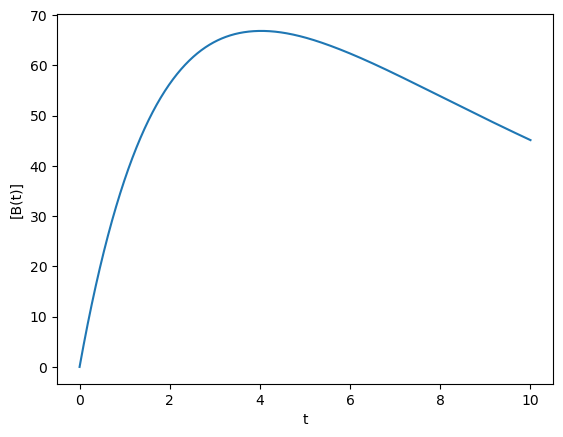

In [29]:
B_t = sol.y[1]   #Concentration of B at various timesteps which we can also plot
t = sol.t        #Gives the time series

plt.plot(t,B_t)
plt.xlabel("t")
plt.ylabel("[B(t)]")
conc = B_t[500]

print(f"The concentration of B at t=5.0s is {conc}")

### The N-Body Problem



The acceleration of ith particle due to the sum of gravitational forces from all other particles j is given by the expression
$$

\vec{a_i} = \sum_{j\neq i}G\cdot m_j \cdot \frac{\vec{r_j} - \vec{r_i}}{|\vec{r_j} - \vec{r_i}|^3}

$$

To solve the issue of singularity when $|\vec{r_j} - \vec{r_i}| \approx 0$ we can introduce a softening parameter $\epsilon$ in the denominator in the following way 

$$

\vec{a_i} = \sum_{j\neq i}G\cdot m_j \cdot \frac{\vec{r_j} - \vec{r_i}}{(|\vec{r_j} - \vec{r_i}|^2 + \epsilon^2)^{3/2} }

$$

with $\epsilon > 0$. This ensures that when $|\vec{r_j} - \vec{r_i}| \approx 0$ you still have a non-zero denominator.

This is also known as Plummer Softening or Newtonian Softening.

Introducing this new parameter does change the physics of the situation so we have to pick just the right value of $\epsilon$ such that we avoid the singularity but also not alter the physics too much.

So the value of $\epsilon$ does affect the results in a way as in picking a $\epsilon$ too small as compared to the inter-body separation will still give you those singularity-like cases of bodies being flung at unphysical speeds. But picking a $\epsilon$ too big will alter the inverse square law too much for it to be of any physical significance. 

The usual rule of thumb for choosing the value of $\epsilon$ (For uniform particle distribution) is that it must be $\approx$ the mean inter-body separation




### Setup and Initialization

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import time

#Simulation Paramaters

G = 1.0              #Gravitational Constant
e = 0.2              #Softening Parameter epsilon
#Since ours is a uniform particle distribution we will choose a value of epsilon to be 0.5.
dt = 0.01            #Time Step
STEPS = 200          #Number of time steps
N_PARTICLES = 100     #Number of Particles

def generate_initial_state(N,seed=42):
    """
    Generates N random particles
    Returns:
            position: (N,2) array
            velocities: (N,2)  array
            masses: (N,) array
    
    """

    np.random.seed(seed)
    positions  = np.random.rand(N,2)        # [x,y] array x & y between 0 and 1
    velocities = np.random.rand(N,2)*0.5    # [v_x,v_y] array v_x and v_y between 0 and 0.5  
    masses = np.random.rand(N) + 0.5        # Masses between 0.5 and 1.5

    return positions, velocities, masses

print("Initial Positions")
print(generate_initial_state(N_PARTICLES)[0])
print("Masses")
print(generate_initial_state(N_PARTICLES)[2])
print("Initial Velocities")
print(generate_initial_state(N_PARTICLES)[1])


Initial Positions
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]
 [0.18182497 0.18340451]
 [0.30424224 0.52475643]
 [0.43194502 0.29122914]
 [0.61185289 0.13949386]
 [0.29214465 0.36636184]
 [0.45606998 0.78517596]
 [0.19967378 0.51423444]
 [0.59241457 0.04645041]
 [0.60754485 0.17052412]
 [0.06505159 0.94888554]
 [0.96563203 0.80839735]
 [0.30461377 0.09767211]
 [0.68423303 0.44015249]
 [0.12203823 0.49517691]
 [0.03438852 0.9093204 ]
 [0.25877998 0.66252228]
 [0.31171108 0.52006802]
 [0.54671028 0.18485446]
 [0.96958463 0.77513282]
 [0.93949894 0.89482735]
 [0.59789998 0.92187424]
 [0.0884925  0.19598286]
 [0.04522729 0.32533033]
 [0.38867729 0.27134903]
 [0.82873751 0.35675333]
 [0.28093451 0.54269608]
 [0.14092422 0.80219698]
 [0.07455064 0.98688694]
 [0.77224477 0.19871568]
 [0.00552212 0.81546143]
 [0.70685734 0.72900717]
 [0.77127035 0.07404465]
 [0.358

In [31]:
position, velocity, mass= generate_initial_state(N_PARTICLES)


def calculate_accelerations(positions, masses, G, e):
    displacement_matrix = positions[None,:] - positions[:,None]   #Broadcasting
    #displacement_matrix[i,j,:] gives displacement vector from i to j

    distance_squared_matrix = np.sum(displacement_matrix**2,axis=-1)  #squares and adds along last axis which is (x,y)

    N = len(masses)

    acceleration_matrix = np.zeros((N,2))   #Creating the acceleration matrix

    for i in range(0,N):
        acceleration_j = 0
        for j in range(0,N):
            acceleration_j += G*masses[j]/(distance_squared_matrix[i,j] + e**2)**(1.5)*displacement_matrix[i,j,:]
        
        acceleration_matrix[i] = acceleration_j
    
    return acceleration_matrix


acceleration = calculate_accelerations(position, mass, G, e)
print(acceleration)

    

[[  25.38218843 -201.4707429 ]
 [ -87.8023801   -60.70215206]
 [ 180.53945387  150.40433101]
 [ 136.88817553 -124.08523633]
 [  -5.68531905 -115.8359422 ]
 [ 133.0776217  -166.5831587 ]
 [-131.62321904  132.37568791]
 [ 172.90754221  135.65218329]
 [  57.58375153  -33.10518647]
 [  11.59102656   73.25317887]
 [ -50.67822684  180.75293558]
 [  91.53673956   53.74973554]
 [  19.84935634 -159.56801602]
 [ 142.99596656  -14.36663237]
 [ -34.3996846   229.20142164]
 [ -51.99663805  160.11225168]
 [ 106.18244389 -171.1235936 ]
 [-199.68448536 -111.351419  ]
 [  85.89757017  206.77999871]
 [ -63.30768077   32.45493916]
 [ 191.96001063    9.80159407]
 [ 142.9456946  -141.07073091]
 [  78.47120706 -107.52818078]
 [  51.89246565  -30.36795363]
 [ -33.32831168  154.99526653]
 [-209.14859112  -90.66756501]
 [-161.65280432 -168.69210581]
 [  -7.6978313  -216.03610132]
 [ 200.51223451  125.04490218]
 [ 221.77282124   74.77555742]
 [  35.09266739   86.11849899]
 [-150.09487305   53.82637552]
 [  75.6

In [32]:
#We will implement velocity-first symplectic euler
#Velocities get updated first and then position.

#We will be implementing only 1 timestep

def symplectic_euler_step(positions, velocities, accelerations, dt):
    velocities = velocities + accelerations*dt
    positions = positions + velocities*dt

    return positions, velocities


    

### Visualization

Simulation of 100 particles for 200 steps took: 4.6789s


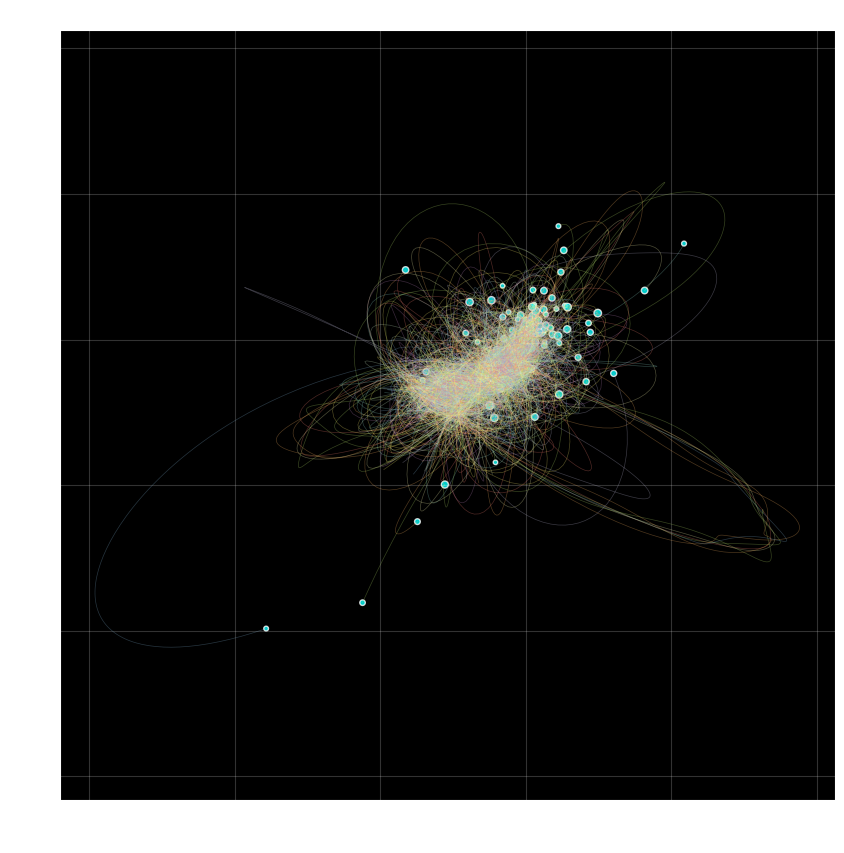

In [33]:

def run_simulation(N, steps, dt):
    positions, velocities, masses = generate_initial_state(N)
    
    trajectory_history = []
    trajectory_history.append(positions.copy())
    
    start_time = time.time()
    
    for _ in range(steps):
        # Calculate forces
        acc = calculate_accelerations(positions, masses, G, e)
        
        # Integrate
        positions, velocities = symplectic_euler_step(positions, velocities, acc, dt)
        
        # Store history
        trajectory_history.append(positions.copy())
        
    end_time = time.time()
    print(f"Simulation of {N} particles for {steps} steps took: {end_time - start_time:.4f}s")
    
    return np.array(trajectory_history), masses

# Main Simualtion
history, masses = run_simulation(N=N_PARTICLES, steps=STEPS, dt=dt)

plt.figure(figsize=(10, 10))
plt.style.use('dark_background')

for i in range(N_PARTICLES):
    plt.plot(history[:, i, 0], history[:, i, 1], alpha=0.3, lw=0.5)

# Plot final positions
plt.scatter(history[-1, :, 0], history[-1, :, 1], s=masses*20, c='cyan', alpha=0.8, edgecolors='white')

plt.title(f"N-Body Simulation (N={N_PARTICLES})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()



### Conservation of Energy

Introducing the softening parameter does change the energy functions.

**Kinetic Energy**

$$
    T = \frac{1}{2} \sum_{i}m_iv_i^2
$$
Kinetic energy term remains unchanged

**Potential Energy**

$$
    U = -\frac{G}{2} \sum_{i\neq j}\frac{m_im_j}{\sqrt{r_{ij}^2 + \epsilon^2}}
$$
Potential energy term gets altered due to the introduction of the softening parameter

In [34]:
def calculate_total_energy(positions, velocities, masses, G, e):
    velocity_squared = np.sum(velocities**2,axis=1)
    T = 0.5*np.sum(masses*velocity_squared)

    displacement_matrix = positions[None,:] - positions[:,None]
    distance_squared_matrix = np.sum(displacement_matrix**2,axis=-1)

    N = len(masses)

    #We will again use broadcasting to calculate cross-mass array (m_i*m_j)
    
    Cross_mass_array = masses[:,None]*masses[None,:]
    
    denominator_matrix = 1/np.sqrt(distance_squared_matrix + e**2)

    Potential_energy_matrix = -G*0.5*denominator_matrix*Cross_mass_array

    np.fill_diagonal(Potential_energy_matrix,0)    #Since we want to exclude i = j we fill the diagonals with 0

    U = np.sum(Potential_energy_matrix)

    return U, T

#Test for a simple 2-body static case

pos_test = np.array([[1.0, 0.0], [-1.0, 0.0]])
vel_test = np.array([[0.0, 0.0], [0.0, 0.0]])
mass_test = np.array([1.0, 1.0])

E_check = calculate_total_energy(pos_test, vel_test, mass_test, G, e)

print(f"Test Case Energy: {E_check} (Expected: U = -0.497512 and K = 0 )")



Test Case Energy: (-0.49751859510499463, 0.0) (Expected: U = -0.497512 and K = 0 )


### Advanced Integration with SciPy

The case with solve_ivp of SciPy is that it requires 1-D arrays only. 

In general it requires 2 1-D arrays.
 1. Initial variable array $[x_1(t), x_2(t), x_3(t), \cdots x_N(t) ]$ 
 2. Derivative array  $[x_1'(t), x_2'(t), x_3'(t), \cdots x_N'(t) ]$

Once you feed SciPy this it will calculate for the next timestep. PS: We might need to recalculate the derivative array at eveery new timestep


 In our case we will need to flatten our arrays to 1-D shape first, calculate the derivative array and then feed both the initial variable array and the derivative array to SciPy for it to solve.

Our initial variable array becomes 

1. $[x_1, y_1, x_2, y_2, \cdots, x_N, y_N, v_{x1}, v_{y1}, v_{x2}, v_{y2}, \cdots, v_{xN}, v_{yN} ]$

And the derivative array is the just the corresponding derivatives, for our case that is velocities and accelerations (for which we will need our compute_acceleration matrix).

2. $[v_{x1}, v_{y1}, v_{x2}, v_{y2}, \cdots, v_{xN}, v_{yN}, a_{x1}, a_{y1}, a_{x2}, a_{y2} \cdots, a_{xN}, a_{yN} ]$



In [ ]:
from scipy.integrate import solve_ivp

#Calculates the derivative array from the initial variable array y

def nbody_ode(t, y, masses, G):
    #We need to first extract the position and velocity matrices from the 1-D array y

    N = len(masses)

    position = y[:2*N].reshape(N,2)   #Position array from first 2N entries
    velocity = y[2*N:].reshape(N,2)   #Velocity array from last 2N entries

    derivative_matrix = np.zeros(4*N,)

    acceleration = calculate_accelerations(position, masses, G, e)

    derivative_matrix[:2*N] = velocity.ravel()
    derivative_matrix[2*N:] = acceleration.ravel()

    return derivative_matrix
    

In [36]:
N_SCIPY = 10
pos_s, vel_s, mass_s = generate_initial_state(N_SCIPY)

t_span_s = (0,2.0)
print(f"Running SciPy Integrator for N={N_SCIPY} particles...")

initial_state_vector = np.zeros(4*N_SCIPY,)

initial_state_vector[:2*N_SCIPY] = pos_s.ravel()
initial_state_vector[2*N_SCIPY:] = vel_s.ravel()

sol = solve_ivp(
    fun=lambda t, y: nbody_ode(t, y, mass_s, G),
    t_span=t_span_s,
    y0=initial_state_vector
)

if sol:
    print(f"SciPy solved in {len(sol.t)} steps.")
    print(f"Final shape of solution: {sol.y.shape}")


Running SciPy Integrator for N=10 particles...
SciPy solved in 44 steps.
Final shape of solution: (40, 44)


### Damped coupled Oscillators


Governing Equations

$$
    \frac{d^2\theta_1}{dt^2} = -c_1 \frac{d\theta_1}{dt} - k_1\theta_1 - k_c(\theta_1 - \theta_2)
$$

$$
    \frac{d^2\theta_2}{dt^2} = -c_2 \frac{d\theta_2}{dt} - k_2\theta_2 - k_c(\theta_2 - \theta_1)
$$

Goal is to find $c_1, c_2, k_1, k_2, k_c$ from the data of $\theta_1$ and $\theta_2$ given to us

data.csv has 50,000 rows of 3 columns [t, $\theta_1$, $\theta_2$] with t going from 0s to 50s

We can always compute the derivatives of $\theta_1$ and $\theta_2$ from the data given using central/forward/backward difference scheme. 

So we have 50,000 equations and 3 unknowns which is a classic over determined system. Not every list of coefficients will solve all the equations so we pick the one which is the best approximate answer.

We solve this using least squares. Given a linear system of equations 
$$
    y = Ax
$$
The least squares solution to this is given by 
$$
    x = (A^TA)^{-1}A^Ty
$$

For our case 

The system of equations can be written as:

$$
\mathbf{y} = \mathbf{A} \mathbf{x}
$$

where 

$$
\mathbf{y} =
\begin{bmatrix}
\ddot{\theta}_1(t_1) \\
\ddot{\theta}_1(t_2) \\
\vdots \\
\ddot{\theta}_1(t_{50000})
\end{bmatrix}, 
\quad
\mathbf{A} =
\begin{bmatrix}
\dot{\theta}_1(t_1) & \theta_1(t_1) & \theta_2(t_1) \\
\dot{\theta}_1(t_2) & \theta_1(t_2) & \theta_2(t_2) \\
\vdots & \vdots & \vdots \\
\dot{\theta}_1(t_{50000}) & \theta_1(t_{50000}) & \theta_2(t_{50000})
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
a \\
b \\
c
\end{bmatrix}
$$


where the matrix $x$ is the coefficients matrix 

$$
    a = -c_1
$$
$$
    b = -(k_1 + k_c)
$$
$$
    c = k_c
$$

A similar matrix equation can be set for the second differential equation as well

In [338]:
import pandas as pd

df = pd.read_csv("data.csv")

t = df["t"].to_numpy()                  #The time array from data.csv
theta1 = df["theta_1"].to_numpy()           #Theta_1 array
theta2 = df["theta_2"].to_numpy()         #Theta_2 array


theta1_dot = np.gradient(theta1,t)
theta2_dot = np.gradient(theta2,t)

theta1_ddot = np.gradient(theta1_dot,t)
theta2_ddot = np.gradient(theta2_dot,t)

A1 = np.column_stack([theta1_dot, theta1, theta2])
y1 = theta1_ddot 

A1TA1 = A1.T@A1
coeff1 = np.linalg.solve(A1TA1, A1.T@y1)


c1 = -coeff1[0]
k_c_1 = coeff1[2]
k_1 = -coeff1[1] - k_c_1

A2 = np.column_stack([theta2_dot, theta2, theta1])
y2 = theta2_ddot

A2TA2 = A2.T@A2
coeff2 = np.linalg.solve(A2TA2,A2.T@y2)


c2 = -coeff2[0]
k_c_2 = coeff2[2]
k_2 = -coeff2[1] - k_c_2 

print("The approximate coefficients from the data given to us is")
print()
print(f"c1 = {c1}")
print()
print(f"c2 = {c2}")
print()
print(f"k_1 = {k_1}")
print()
print(f"k_2 = {k_2}")
print()
print(f"k_c = {(k_c_1+k_c_2)/2}")



The approximate coefficients from the data given to us is

c1 = 7.137948707446148

c2 = -46.370041853383185

k_1 = 182366.48017920286

k_2 = 208098.81456808076

k_c = -55647.63786439506
